# Baseline Model 2: BiLSTM (PyTorch) cho Phân loại Khiếu nại

Notebook này huấn luyện mô hình **Bidirectional LSTM** bằng PyTorch để phân loại các review là khiếu nại (1) hoặc không (0) từ dữ liệu Shopee.

**Dữ liệu:** `data/processed/shopee_mapped.csv`  
**Mô hình:** BiLSTM + Embedding + PyTorch  
**Đánh giá:** Classification Report, Confusion Matrix, Training/Validation Loss Curves

## Bước 1: Import thư viện & Cấu hình thiết bị

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Thêm đường dẫn root vào sys.path để import được hàm clean_vietnamese_text
ROOT_DIR = os.path.abspath('..')
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from src.utils.utils import clean_vietnamese_text

# Cấu hình thiết bị (Device)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[OK] Sử dụng device: {device}")
if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")
    print(f"[INFO] CUDA version: {torch.version.cuda}")
    print(f"[INFO] PyTorch version: {torch.__version__}")

# Set seed để tái tạo được kết quả
torch.manual_seed(42)
np.random.seed(42)

print("\n[OK] Tất cả thư viện đã import thành công!")

[OK] Sử dụng device: cpu

[OK] Tất cả thư viện đã import thành công!


## Bước 2: Tải và Làm sạch dữ liệu

In [2]:
# Đọc dữ liệu
data_path = '../data/processed/shopee_mapped.csv'
print(f"[INFO] Đang đọc file từ: {data_path}")
df = pd.read_csv(data_path, encoding='utf-8-sig')

print(f"[INFO] Số dòng ban đầu: {len(df)}")

# Xóa các dòng NaN ở cột 'review'
print(f"[INFO] Số NaN ở cột review trước: {df['review'].isna().sum()}")
df = df.dropna(subset=['review']).reset_index(drop=True)
print(f"[OK] Xóa xong NaN. Số dòng còn lại: {len(df)}")

# Áp dụng hàm clean_vietnamese_text để tạo cột mới 'cleaned_text'
print("\n[INFO] Đang làm sạch văn bản (Clean Vietnamese Text)...")
df['cleaned_text'] = df['review'].apply(lambda x: clean_vietnamese_text(str(x)))
print("[OK] Làm sạch xong!")

# Chia tập dữ liệu Train/Test (80/20)
print("\n[INFO] Chia tập dữ liệu: 80% train, 20% test")
X = df['cleaned_text'].values
y = df['complaint_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"[OK] Chia xong!")
print(f"[INFO] Kích thước train set: {len(X_train)} mẫu")
print(f"[INFO] Kích thước test set: {len(X_test)} mẫu")
print(f"\n[INFO] Phân phối nhãn trong train set:")
print(pd.Series(y_train).value_counts())
print(f"\n[INFO] Phân phối nhãn trong test set:")
print(pd.Series(y_test).value_counts())

# Lưu để sử dụng ở bước sau
train_texts = X_train
test_texts = X_test
train_labels = y_train
test_labels = y_test

[INFO] Đang đọc file từ: ../data/processed/shopee_mapped.csv
[INFO] Số dòng ban đầu: 7817
[INFO] Số NaN ở cột review trước: 0
[OK] Xóa xong NaN. Số dòng còn lại: 7817

[INFO] Đang làm sạch văn bản (Clean Vietnamese Text)...
[OK] Làm sạch xong!

[INFO] Chia tập dữ liệu: 80% train, 20% test
[OK] Chia xong!
[INFO] Kích thước train set: 6253 mẫu
[INFO] Kích thước test set: 1564 mẫu

[INFO] Phân phối nhãn trong train set:
1    3361
0    2892
Name: count, dtype: int64

[INFO] Phân phối nhãn trong test set:
1    841
0    723
Name: count, dtype: int64


## Bước 3: Xây dựng Từ điển (Vocabulary) & Tokenization

In [3]:
# Cấu hình cho vocabulary
VOCAB_SIZE = 10000
PAD_IDX = 0
UNK_IDX = 1
MAX_LENGTH = 50

# Xây dựng từ điển từ tập Train
print("[INFO] Xây dựng từ điển (Vocabulary)...")

# Tokenize từng câu và đếm tần suất từ
word_freq = Counter()
for text in train_texts:
    words = text.split()
    word_freq.update(words)

# Lấy 10000 từ phổ biến nhất (giữ lại PAD và UNK)
most_common_words = word_freq.most_common(VOCAB_SIZE - 2)
print(f"[INFO] Tổng từ vựng: {len(word_freq)} từ")
print(f"[INFO] Số từ được giữ lại: {len(most_common_words)} từ (+ PAD, UNK)")

# Tạo word2idx mapping
word2idx = {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX}
for idx, (word, freq) in enumerate(most_common_words, start=2):
    word2idx[word] = idx

# Tạo idx2word mapping (dùng để decode nếu cần)
idx2word = {idx: word for word, idx in word2idx.items()}

print(f"[OK] Tạo từ điển thành công! Kích thước: {len(word2idx)}")
print(f"[INFO] Mẫu từ: {list(word2idx.items())[:5]}")

# Hàm chuyển đổi text thành indices
def text_to_indices(text, word2idx, max_length=MAX_LENGTH):
    """
    Chuyển đổi text thành chuỗi indices
    - Tokenize text thành từ
    - Map mỗi từ sang index (sử dụng UNK nếu từ không có trong vocab)
    - Padding/Truncating để độ dài = max_length
    """
    words = text.split()
    indices = []
    
    for word in words:
        if word in word2idx:
            indices.append(word2idx[word])
        else:
            indices.append(UNK_IDX)
    
    # Truncate nếu quá dài
    if len(indices) > max_length:
        indices = indices[:max_length]
    
    # Padding nếu quá ngắn
    while len(indices) < max_length:
        indices.append(PAD_IDX)
    
    return indices

# Chuyển đổi dữ liệu
print("\n[INFO] Chuyển đổi text thành indices...")
train_indices = np.array([text_to_indices(text, word2idx) for text in tqdm(train_texts, desc="Train")])
test_indices = np.array([text_to_indices(text, word2idx) for text in tqdm(test_texts, desc="Test")])

print(f"[OK] Train indices shape: {train_indices.shape}")
print(f"[OK] Test indices shape: {test_indices.shape}")
print(f"\n[INFO] Mẫu indices: {train_indices[0]}")

[INFO] Xây dựng từ điển (Vocabulary)...
[INFO] Tổng từ vựng: 9072 từ
[INFO] Số từ được giữ lại: 9072 từ (+ PAD, UNK)
[OK] Tạo từ điển thành công! Kích thước: 9074
[INFO] Mẫu từ: [('<PAD>', 0), ('<UNK>', 1), ('hàng', 2), ('không', 3), ('mua', 4)]

[INFO] Chuyển đổi text thành indices...


Test: 100%|██████████| 1564/1564 [00:00<00:00, 179388.85it/s]

[OK] Train indices shape: (6253, 50)
[OK] Test indices shape: (1564, 50)

[INFO] Mẫu indices: [  69   77  109  103   14  335 4344    7    2   54  547   58    8  786
  144  188   44   17    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]


## Bước 4: Tạo PyTorch Dataset & DataLoader

In [4]:
# Định nghĩa ReviewDataset kế thừa từ torch.utils.data.Dataset
class ReviewDataset(Dataset):
    """
    Custom Dataset cho các review texts.
    Trả về: (text_indices, label)
    """
    def __init__(self, text_indices, labels):
        self.text_indices = text_indices
        self.labels = labels
    
    def __len__(self):
        return len(self.text_indices)
    
    def __getitem__(self, idx):
        text_idx = torch.tensor(self.text_indices[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return text_idx, label

# Tạo Dataset instances
print("[INFO] Tạo Dataset instances...")
train_dataset = ReviewDataset(train_indices, train_labels)
test_dataset = ReviewDataset(test_indices, test_labels)

# Tạo DataLoaders
print("[INFO] Tạo DataLoaders...")
batch_size = 64
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0  # Đặt 0 trên Windows để tránh lỗi multiprocessing
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

print(f"[OK] Train DataLoader: {len(train_loader)} batches (batch_size={batch_size})")
print(f"[OK] Test DataLoader: {len(test_loader)} batches (batch_size={batch_size})")

# In mẫu một batch
print("\n[INFO] Mẫu batch từ train_loader:")
for batch_idx, (texts, labels) in enumerate(train_loader):
    print(f"  Texts shape: {texts.shape}")  # (batch_size, max_length)
    print(f"  Labels shape: {labels.shape}")  # (batch_size,)
    print(f"  Sample label: {labels[0]}")
    break

[INFO] Tạo Dataset instances...
[INFO] Tạo DataLoaders...
[OK] Train DataLoader: 98 batches (batch_size=64)
[OK] Test DataLoader: 25 batches (batch_size=64)

[INFO] Mẫu batch từ train_loader:
  Texts shape: torch.Size([64, 50])
  Labels shape: torch.Size([64])
  Sample label: 0


## Bước 5: Định nghĩa kiến trúc mạng BiLSTM

In [5]:
# Định nghĩa BiLSTM Classifier
class BiLSTMClassifier(nn.Module):
    """
    Kiến trúc BiLSTM cho phân loại văn bản:
    - Embedding layer: Chuyển word indices thành embeddings
    - BiLSTM layer: 2 layers, bidirectional, với dropout
    - Fully connected layer: Phân loại thành 2 lớp (0: Normal, 1: Complaint)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, output_dim, dropout_rate=0.3):
        super(BiLSTMClassifier, self).__init__()
        
        # Embedding layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=PAD_IDX
        )
        
        # Bidirectional LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout_rate if num_layers > 1 else 0
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout_rate)
        
        # Fully connected layer (output)
        # Input: hidden_dim * 2 (vì bidirectional)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
    
    def forward(self, text_indices):
        """
        Input: text_indices (batch_size, max_length)
        Output: logits (batch_size, output_dim)
        """
        # Embedding
        embedded = self.embedding(text_indices)  # (batch, max_len, embed_dim)
        embedded = self.dropout(embedded)
        
        # BiLSTM
        output, (hidden, cell) = self.lstm(embedded)  # output: (batch, max_len, hidden_dim*2)
        # hidden: (num_layers*2, batch, hidden_dim)
        
        # Lấy hidden state cuối cùng từ cả forward và backward
        hidden_fwd = hidden[-2, :, :]  # Forward layer cuối
        hidden_bwd = hidden[-1, :, :]  # Backward layer cuối
        context = torch.cat([hidden_fwd, hidden_bwd], dim=1)  # (batch, hidden_dim*2)
        
        # Dropout
        context = self.dropout(context)
        
        # Fully connected
        logits = self.fc(context)  # (batch, 2)
        
        return logits

# Cấu hình mô hình
embed_dim = 128
hidden_dim = 128
num_layers = 2
output_dim = 2  # 2 classes: 0 (Normal), 1 (Complaint)
dropout_rate = 0.3

print("[INFO] Tạo mô hình BiLSTMClassifier...")
model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    output_dim=output_dim,
    dropout_rate=dropout_rate
)

# Đưa mô hình lên device
model.to(device)

# In kiến trúc mô hình
print("\n[INFO] Kiến trúc mô hình:")
print(model)

# Tính số tham số
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n[INFO] Số tham số cần huấn luyện: {count_parameters(model):,}")

[INFO] Tạo mô hình BiLSTMClassifier...

[INFO] Kiến trúc mô hình:
BiLSTMClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

[INFO] Số tham số cần huấn luyện: 1,939,970


## Bước 6: Cấu hình Huấn luyện (Training Loop)

In [6]:
# Cấu hình training
learning_rate = 0.001
num_epochs = 10

# Hàm mất mát (Loss function)
# Tính trọng số class để cân bằng dữ liệu không cân bằng
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print(f"[INFO] Cấu hình training:")
print(f"  - Epochs: {num_epochs}")
print(f"  - Learning rate: {learning_rate}")
print(f"  - Batch size: {batch_size}")
print(f"  - Loss function: CrossEntropyLoss (với class weights)")
print(f"  - Optimizer: Adam")
print(f"  - Class weights: {class_weights.cpu().numpy()}")

# Danh sách lưu metrics
train_losses = []
train_accs = []
test_losses = []
test_accs = []

# Hàm huấn luyện một epoch
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    
    for batch_idx, (texts, labels) in enumerate(tqdm(dataloader, desc="Training", leave=False)):
        texts = texts.to(device)
        labels = labels.to(device)
        
        # Forward pass
        logits = model(texts)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate metrics
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
    
    avg_loss = total_loss / len(dataloader)
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc

# Hàm đánh giá một epoch
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for texts, labels in tqdm(dataloader, desc="Evaluating", leave=False):
            texts = texts.to(device)
            labels = labels.to(device)
            
            # Forward pass
            logits = model(texts)
            loss = criterion(logits, labels)
            
            # Accumulate metrics
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    avg_acc = total_correct / total_samples
    return avg_loss, avg_acc, np.array(all_preds), np.array(all_labels)

# Vòng lặp huấn luyện
print(f"\n[INFO] Bắt đầu huấn luyện...")
print("="*70)

for epoch in range(num_epochs):
    # Huấn luyện
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Đánh giá
    test_loss, test_acc, test_preds, test_true_labels = evaluate(model, test_loader, criterion, device)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

print("="*70)
print(f"[OK] Huấn luyện xong!")

# Lưu dự đoán cuối cùng
final_test_preds = test_preds
final_test_labels = test_true_labels

[INFO] Cấu hình training:
  - Epochs: 10
  - Learning rate: 0.001
  - Batch size: 64
  - Loss function: CrossEntropyLoss (với class weights)
  - Optimizer: Adam
  - Class weights: [0.00034578 0.00029753]

[INFO] Bắt đầu huấn luyện...


Epoch  1/10 | Train Loss: 0.4433 | Train Acc: 0.7940 | Test Loss: 0.2796 | Test Acc: 0.8887


Epoch  2/10 | Train Loss: 0.2658 | Train Acc: 0.8973 | Test Loss: 0.2372 | Test Acc: 0.9111


Epoch  3/10 | Train Loss: 0.2109 | Train Acc: 0.9186 | Test Loss: 0.2439 | Test Acc: 0.9214


Epoch  4/10 | Train Loss: 0.1762 | Train Acc: 0.9384 | Test Loss: 0.2313 | Test Acc: 0.9182


...

Epoch  6/10 | Train Loss: 0.1365 | Train Acc: 0.9515 | Test Loss: 0.2374 | Test Acc: 0.9239


Epoch  7/10 | Train Loss: 0.1060 | Train Acc: 0.9645 | Test Loss: 0.2526 | Test Acc: 0.9201


Epoch  8/10 | Train Loss: 0.1046 | Train Acc: 0.9618 | Test Loss: 0.2695 | Test Acc: 0.9214


Epoch  9/10 | Train Loss: 0.0897 | Train Acc: 0.9707 | Test Loss: 0.2662 | Test Acc: 0.9252


Epoch 10/10 | Train Loss: 0.0691 | Train Acc: 0.9778 | Test Loss: 0.2779 | Test Acc: 0.9239
[OK] Huấn luyện xong!


## Bước 7: Đánh giá & Vẽ biểu đồ

In [7]:
# In Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT (Precision, Recall, F1-score)")
print("="*70)
print(classification_report(
    final_test_labels, 
    final_test_preds, 
    target_names=['Bình thường (0)', 'Khiếu nại (1)']
))
print("="*70)

# Tính Accuracy
accuracy = accuracy_score(final_test_labels, final_test_preds)
print(f"\n[INFO] Accuracy trên tập test: {accuracy:.4f}")

# Tính Confusion Matrix
cm = confusion_matrix(final_test_labels, final_test_preds)
print(f"\n[INFO] Confusion Matrix:")
print(f"  - True Negative (TN):  {cm[0, 0]} (Dự đoán đúng: không khiếu nại)")
print(f"  - False Positive (FP): {cm[0, 1]} (Dự đoán sai: khiếu nại)")
print(f"  - False Negative (FN): {cm[1, 0]} (Dự đoán sai: không khiếu nại)")
print(f"  - True Positive (TP):  {cm[1, 1]} (Dự đoán đúng: khiếu nại)")


CLASSIFICATION REPORT (Precision, Recall, F1-score)
                 precision    recall  f1-score   support

Bình thường (0)       0.90      0.93      0.92       723
  Khiếu nại (1)       0.94      0.92      0.93       841

       accuracy                           0.92      1564
      macro avg       0.92      0.92      0.92      1564
   weighted avg       0.92      0.92      0.92      1564


[INFO] Accuracy trên tập test: 0.9239

[INFO] Confusion Matrix:
  - True Negative (TN):  675 (Dự đoán đúng: không khiếu nại)
  - False Positive (FP): 48 (Dự đoán sai: khiếu nại)
  - False Negative (FN): 71 (Dự đoán sai: không khiếu nại)
  - True Positive (TP):  770 (Dự đoán đúng: khiếu nại)



[INFO] Vẽ biểu đồ Confusion Matrix...


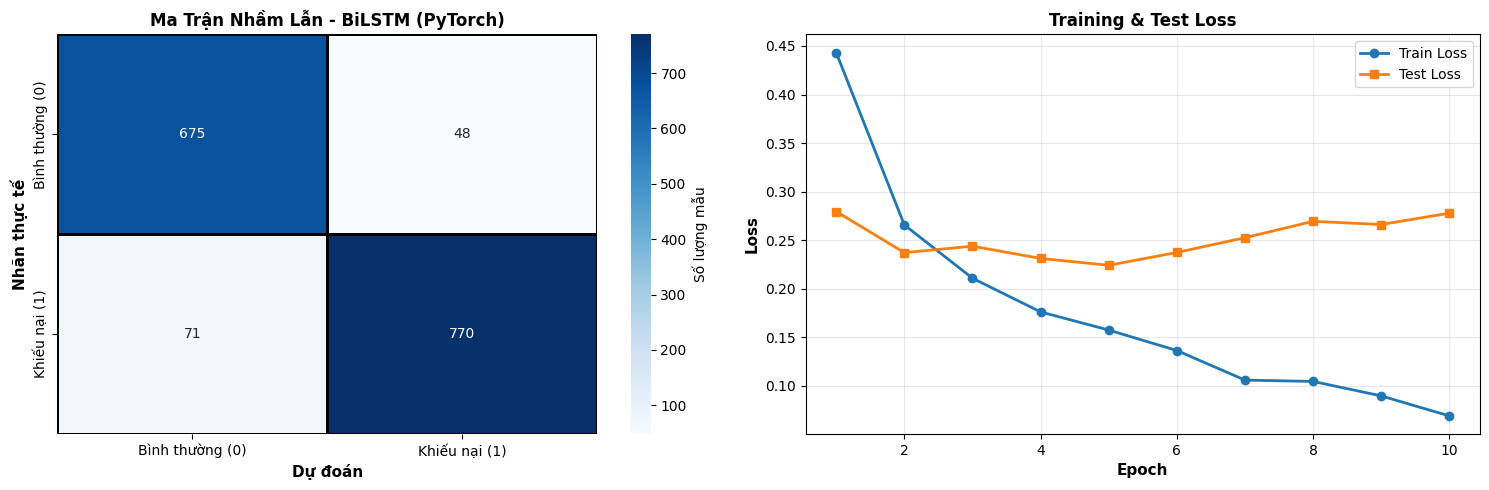

[OK] Biểu đồ đã được lưu tại: data/processed/bilstm_evaluation.png


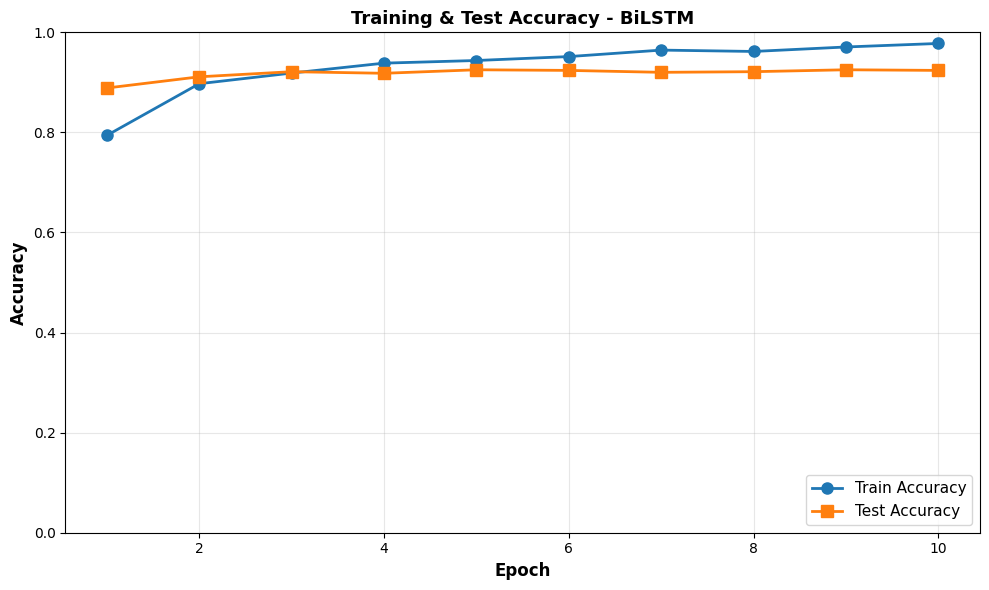

[OK] Biểu đồ Accuracy đã được lưu tại: data/processed/bilstm_accuracy.png


In [8]:
# Vẽ Confusion Matrix
print("\n[INFO] Vẽ biểu đồ Confusion Matrix...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix heatmap
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bình thường (0)', 'Khiếu nại (1)'],
    yticklabels=['Bình thường (0)', 'Khiếu nại (1)'],
    cbar_kws={'label': 'Số lượng mẫu'},
    linewidths=2,
    linecolor='black',
    ax=axes[0]
)
axes[0].set_title('Ma Trận Nhầm Lẫn - BiLSTM (PyTorch)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dự đoán', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Nhãn thực tế', fontsize=11, fontweight='bold')

# Training Loss & Accuracy curves
epochs_range = range(1, num_epochs + 1)
axes[1].plot(epochs_range, train_losses, marker='o', label='Train Loss', linewidth=2)
axes[1].plot(epochs_range, test_losses, marker='s', label='Test Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[1].set_title('Training & Test Loss', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/bilstm_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("[OK] Biểu đồ đã được lưu tại: data/processed/bilstm_evaluation.png")

# Vẽ Accuracy curves
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(epochs_range, train_accs, marker='o', label='Train Accuracy', linewidth=2, markersize=8)
ax.plot(epochs_range, test_accs, marker='s', label='Test Accuracy', linewidth=2, markersize=8)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training & Test Accuracy - BiLSTM', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('../data/processed/bilstm_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("[OK] Biểu đồ Accuracy đã được lưu tại: data/processed/bilstm_accuracy.png")